Importing library

In [21]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, Sequential, optimizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report


# 1. Konfigurasi & Path Dataset

In [22]:
BATCH_SIZE = 32
IMAGE_SIZE = (160, 160)
SEED = 42


base_dir = r"../datasets/project2/cnn"
train_dir =  os.path.join(base_dir, "train")
test_dir =  os.path.join(base_dir, "test")
valid_dir =  os.path.join(base_dir, "valid")



# 2. Split dataset 
train 70%, test 15%, valid 15%

In [23]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    label_mode = 'int',
    image_size =IMAGE_SIZE,
    batch_size = BATCH_SIZE,
    shuffle = True,
    seed =SEED
)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    label_mode = 'int',
    image_size =IMAGE_SIZE,
    batch_size = BATCH_SIZE,
    shuffle = True,
    seed =SEED
)
valid_ds = tf.keras.preprocessing.image_dataset_from_directory(
    valid_dir,
    label_mode = 'int',
    image_size =IMAGE_SIZE,
    batch_size = BATCH_SIZE,
    shuffle = True,
    seed =SEED
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Clasess: {class_names}")
print(f"Jumlah class : {num_classes}")
# Simpan nama kelas untuk digunakan di API
with open("dat_and_dog.json", "w") as f:
    json.dump(class_names, f)

Found 17498 files belonging to 2 classes.
Found 3748 files belonging to 2 classes.
Found 3752 files belonging to 2 classes.
Clasess: ['Cat', 'Dog']
Jumlah class : 2


# 3. Menampilkan sampel data

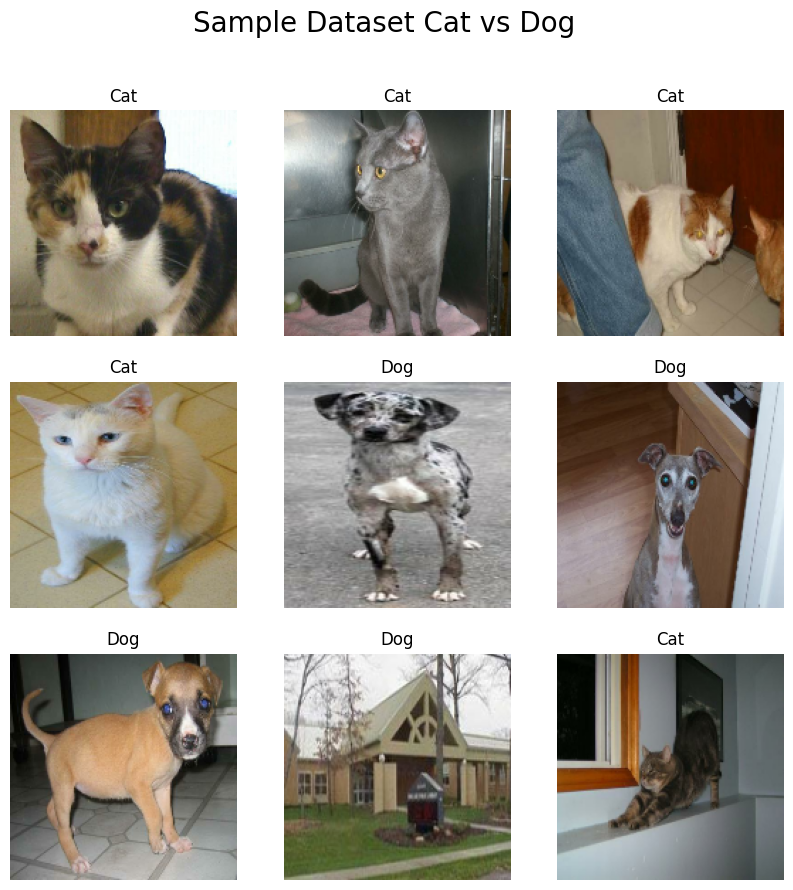

In [24]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):

    plt.figure(figsize=(10,10))

    # MAIN TITLE
    plt.suptitle("Sample Dataset Cat vs Dog", fontsize=20)

    for i in range(9):
        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])

        plt.axis("off")

    plt.show()

# 4. Mencari file gambar yang corrupt dan di repair

Di repair

In [25]:
from PIL import Image
import os
folders = [
    "../datasets/project2/cnn/train",
    "../datasets/project2/cnn/valid",
    "../datasets/project2/cnn/test"
]
for dataset_path in folders:
    print(f"\nChecking: {dataset_path}")
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                with Image.open(file_path) as img:
                    rgb_img = img.convert("RGB")
                    rgb_img.save(file_path, "JPEG")
            except Exception as e:

                print("Hapus:", file_path)
                print("Error:", e)

                os.remove(file_path)


Checking: ../datasets/project2/cnn/train

Checking: ../datasets/project2/cnn/valid

Checking: ../datasets/project2/cnn/test


# 5. Menghitung bobot kelas

In [26]:
y_train = np.concatenate([y for x, y in train_ds], axis=0)
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(weights))

print("Bobot kelas untuk menyeimbangkan training:")
for i, name in enumerate(class_names):
    print(f"  {name}: {class_weight_dict[i]:.2f}")

Bobot kelas untuk menyeimbangkan training:
  Cat: 1.00
  Dog: 1.00


# 6. Bangun model mobilenetv2

In [27]:
from tensorflow.keras.models import Sequential
import numpy as np
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten
@tf.keras.utils.register_keras_serializable()
def preprocess_input(x):
    return tf.keras.applications.mobilenet_v2.preprocess_input(x)

# Augmentasi data ringan untuk membantu generalisasi
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
])

# Base model: MobileNetV2
base_model = MobileNetV2(input_shape=IMAGE_SIZE + (3,), include_top=False, weights='imagenet')
base_model.trainable = False  # Bekukan untuk Tahap 1

# model = models.Sequential([
#     layers.Input(shape=IMAGE_SIZE + (3,)),
#     data_augmentation,
#     layers.Lambda(preprocess_input),
#     base_model,
#     layers.GlobalAveragePooling2D(),
#     layers.Dense(128, activation='relu'),
#     layers.Dropout(0.3),
#     layers.Dense(1, activation='sigmoid')
# ])
model = Sequential([
    Conv2D(32, (3,3), activation= 'relu', input_shape=(160,160,3)),
    MaxPooling2D((2,2)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])


model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    # loss='sparse_categorical_crossentropy',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/home/pratama/dev-python/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 158, 158, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 79, 79, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 77, 77, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 38, 38, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 46208)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     2,957,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,967,585 (11.32 MB)

 Trainable params: 2,967,585 (11.32 MB)

 Non-trainable params: 0 (0.00 B)

# 7. Training tahap 1 : data extraction

In [28]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-7, verbose=1)
]

print("Melatih layer kepala...")
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Melatih layer kepala...
Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 141s 251ms/step - accuracy: 0.4988 - loss: 1.0902 - val_accuracy: 0.5000 - val_loss: 0.6931 - learning_rate: 1.0000e-04
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 130s 238ms/step - accuracy: 0.4971 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931 - learning_rate: 1.0000e-04
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 128s 234ms/step - accuracy: 0.4984 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931 - learning_rate: 1.0000e-04
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 146s 242ms/step - accuracy: 0.4955 - loss: 0.6932 - val_accuracy: 0.5003 - val_loss: 0.6931 - learning_rate: 1.0000e-04
Epoch 5/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.4985 - loss: 0.6931
Epoch 5: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
547/547 ━━━━━━━━━━━━━━━━━━━━ 129s 236ms/step - accuracy: 0.4944 - loss: 0.6932 - val_accuracy: 0.5003 - val_loss: 0.6931 - learning_rate: 1.0000e-04
Epoch 6/10
547/547 ━━━

# 8. Training tahap 2 : Fine Tuning

In [29]:
print("Membuka base model untuk fine-tuning...")
base_model.trainable = True

# Bekukan hingga layer 100
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),  # LR sangat rendah agar tidak merusak bobot pre-trained
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=5,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Membuka base model untuk fine-tuning...
Epoch 1/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 135s 242ms/step - accuracy: 0.4983 - loss: 0.6931 - val_accuracy: 0.5003 - val_loss: 0.6931 - learning_rate: 1.0000e-05
Epoch 2/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 133s 243ms/step - accuracy: 0.4968 - loss: 0.6931 - val_accuracy: 0.5003 - val_loss: 0.6931 - learning_rate: 1.0000e-05
Epoch 3/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 133s 243ms/step - accuracy: 0.4993 - loss: 0.6931 - val_accuracy: 0.5003 - val_loss: 0.6931 - learning_rate: 1.0000e-05
Epoch 4/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.4977 - loss: 0.6931
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
547/547 ━━━━━━━━━━━━━━━━━━━━ 132s 242ms/step - accuracy: 0.4984 - loss: 0.6931 - val_accuracy: 0.5003 - val_loss: 0.6931 - learning_rate: 1.0000e-05
Epoch 5/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 132s 242ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5003 - val_loss: 0.6931 - learning_rate: 2.0000e-06
Restoring m

# 9. Evaluasi model

118/118 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - accuracy: 0.5003 - loss: 0.6931
Test Accuracy: 50.03%
118/118 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

         Cat       0.50      1.00      0.67      1874
         Dog       0.00      0.00      0.00      1874

    accuracy                           0.50      3748
   macro avg       0.25      0.50      0.33      3748
weighted avg       0.25      0.50      0.33      3748



/home/pratama/dev-python/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/pratama/dev-python/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/pratama/dev-python/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

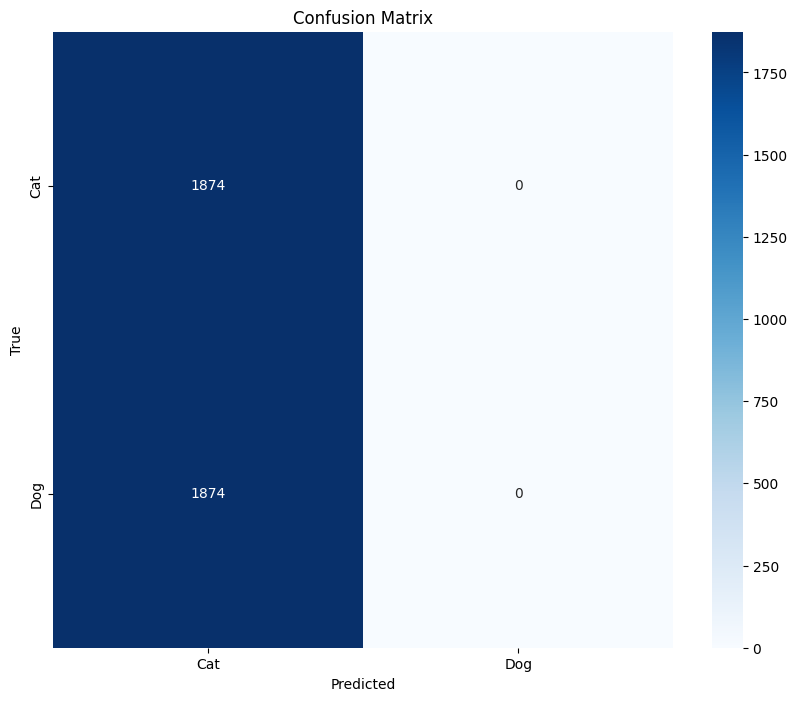

In [30]:
# Evaluasi pada dataset test
loss, acc = model.evaluate(test_ds)
print(f"Test Accuracy: {acc*100:.2f}%")

y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred = np.argmax(model.predict(test_ds), axis=1)

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# 10. Plot kurva belajar

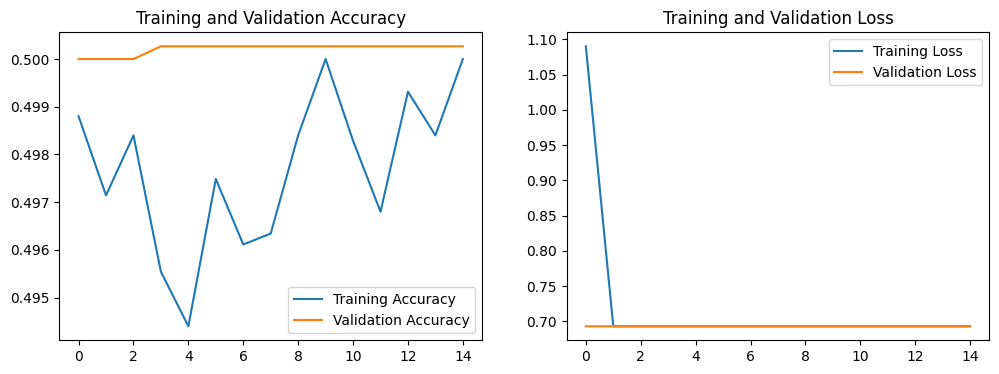

In [31]:
acc_history = history.history['accuracy'] + history_fine.history['accuracy']
val_acc_history = history.history['val_accuracy'] + history_fine.history['val_accuracy']
loss_history = history.history['loss'] + history_fine.history['loss']
val_loss_history = history.history['val_loss'] + history_fine.history['val_loss']

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc_history, label='Training Accuracy')
plt.plot(val_acc_history, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss_history, label='Training Loss')
plt.plot(val_loss_history, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# 11. Simpan model

In [32]:
nama_model = "cat_vs_dogv1.keras"
model.save(nama_model)
print(f"Model disimpan sebagai {nama_model}")

Model disimpan sebagai cat_vs_dogv1.keras
